<a href="https://colab.research.google.com/github/naurasafina/python-google-colab-projek/blob/main/Prediksi_Indeks_Saham_Gabungan_IHSG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

Load Data

In [ ]:
file_name = 'Jakarta_Stock_Exchange_Composite_Index _istorical_Data.csv'
df = pd.read_csv(file_name, sep=';')

print(df.head())
print(f"\nTotal Baris Data Mentah: {len(df)}")
print(df.dtypes)

         Date     Price      Open      High       Low    Vol. Change %
0  07/01/2026  5,695.12  5,640.61  5,737.74  5,607.45  15.76B     0,92
1  06/30/2026  5,643.19  5,801.45  5,811.67  5,638.57  17.75B    -3,05
2  06/29/2026  5,820.79  5,932.03  5,942.77  5,800.29  11.78B    -1,28
3  06/26/2026  5,896.13  6,010.34  6,045.26  5,830.14  17.20B    -1,72
4  06/25/2026  5,999.04  5,873.07  6,056.20  5,864.00  18.79B     1,96

Total Baris Data Mentah: 476
Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object


EDA

In [ ]:
df_eda = df.copy()
df_eda['Price'] = df_eda['Price'].astype(str).str.replace(',', '', regex=False).astype(float)

print("Statistik Deskriptif IHSG (kolom Price):")
print(df_eda['Price'].describe())


Statistik Deskriptif IHSG (kolom Price):
count     476.000000
mean     7426.220042
std       725.513635
min      5342.140000
25%      7034.942500
50%      7326.370000
75%      7917.427500
max      9134.700000
Name: Price, dtype: float64


Preprocessing

In [ ]:
# Bersihkan kolom harga (hapus tanda koma ribuan, ubah ke float)
kolom_harga = ['Price', 'Open', 'High', 'Low']
for k in kolom_harga:
    df[k] = df[k].astype(str).str.replace(',', '', regex=False).astype(float)

# Bersihkan kolom Volume (hapus "B", ubah ke angka miliar)
df['Vol.'] = df['Vol.'].astype(str).str.replace('B', '', regex=False)
df['Vol.'] = pd.to_numeric(df['Vol.'], errors='coerce')

# Bersihkan kolom Change % (hapus tanda %, ubah ke float)
df['Change %'] = df['Change %'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Ganti nama kolom Price jadi IHSG supaya lebih jelas maknanya
df = df.rename(columns={'Price': 'IHSG'})

# Cek missing value
print("Jumlah missing value per kolom:")
print(df.isnull().sum())

# Buang missing value
df = df.dropna().reset_index(drop=True)

# Cek dan buang duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {jumlah_duplikat}")
df = df.drop_duplicates()

# Perbaiki tipe data tanggal (format asli MM/DD/YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Urutkan kronologis (data asli terurut terbaru -> terlama)
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nTotal baris setelah preprocessing: {len(df)}")
print(f"Rentang tanggal: {df['Date'].min().date()} sampai {df['Date'].max().date()}")
print(df.describe())

Jumlah missing value per kolom:
Date        0
IHSG        0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

Jumlah baris duplikat: 0

Total baris setelah preprocessing: 476
Rentang tanggal: 2024-07-01 sampai 2026-07-01
                                Date         IHSG         Open         High  \
count                            476   476.000000   476.000000   476.000000   
mean   2025-06-24 22:02:01.008403456  7426.220042  7439.689202  7482.980063   
min              2024-07-01 00:00:00  5342.140000  5344.690000  5523.940000   
25%              2024-12-16 18:00:00  7034.942500  7066.555000  7090.187500   
50%              2025-07-02 12:00:00  7326.370000  7345.025000  7382.285000   
75%              2025-12-18 06:00:00  7917.427500  7912.830000  7952.070000   
max              2026-07-01 00:00:00  9134.700000  9156.190000  9174.470000   
std                              NaN   725.513635   723.671498   716.613981   

               Low        Vol.   

Identifikasi Pola

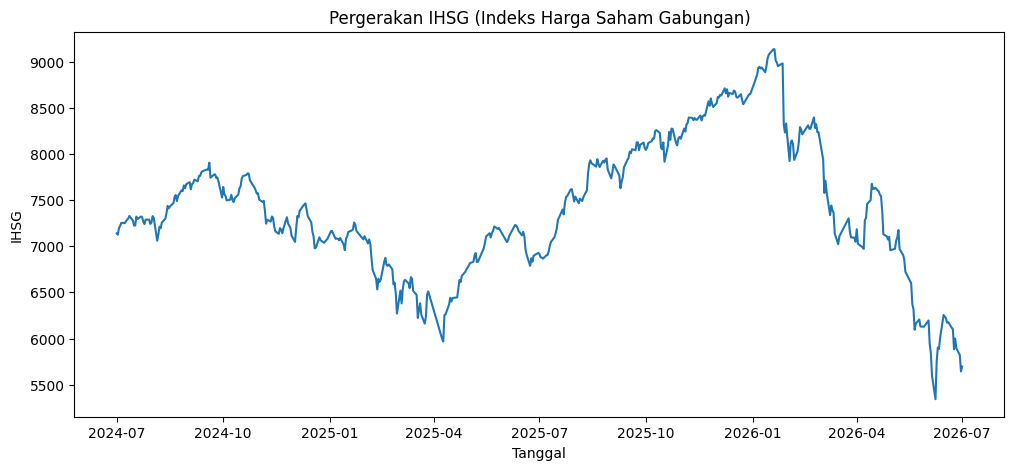

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['IHSG'])
plt.title('Pergerakan IHSG (Indeks Harga Saham Gabungan)')
plt.xlabel('Tanggal')
plt.ylabel('IHSG')
plt.show()

In [ ]:
# Cek seberapa besar hubungan IHSG hari ini dengan IHSG hari-hari sebelumnya
korelasi_lag1 = df['IHSG'].corr(df['IHSG'].shift(1))
korelasi_lag7 = df['IHSG'].corr(df['IHSG'].shift(7))

print(f"Korelasi IHSG dengan IHSG 1 hari sebelumnya: {korelasi_lag1:.4f}")
print(f"Korelasi IHSG dengan IHSG 7 hari sebelumnya: {korelasi_lag7:.4f}")

Korelasi IHSG dengan IHSG 1 hari sebelumnya: 0.9907
Korelasi IHSG dengan IHSG 7 hari sebelumnya: 0.9216


Feature Engineering

In [ ]:
df['Lag_1Hari'] = df['IHSG'].shift(1)
df['Lag_7Hari'] = df['IHSG'].shift(7)
df['Momentum'] = df['Lag_1Hari'] - df['Lag_7Hari']  # arah tren jangka pendek
df['Volume'] = df['Vol.'].shift(1)  # volume perdagangan hari sebelumnya
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

# Target: selisih (perubahan) harga IHSG dari hari sebelumnya, bukan harga langsung
df['Target_Selisih'] = df['IHSG'] - df['Lag_1Hari']

df = df.dropna().reset_index(drop=True)

print(f"Total baris setelah tambah fitur: {len(df)}")
df.head()

Total baris setelah tambah fitur: 469


,Date,IHSG,Open,High,Low,Vol.,Change %,Lag_1Hari,Lag_7Hari,Momentum,Volume,DayOfWeek,Month,Target_Selisih
0,2024-07-10,7287.04,7283.19,7313.20,7272.12,21.43,0.24,7269.80,7139.63,130.17,13.61,2,7,17.24
1,2024-07-11,7300.41,7302.50,7328.27,7274.06,14.64,0.18,7287.04,7125.14,161.90,21.43,3,7,13.37
2,2024-07-12,7327.58,7336.48,7354.16,7300.75,13.07,0.37,7300.41,7196.75,103.66,14.64,4,7,27.17
3,2024-07-15,7278.86,7336.31,7346.10,7252.81,10.74,-0.66,7327.58,7220.89,106.69,13.07,0,7,-48.72
4,2024-07-16,7224.29,7289.81,7294.79,7213.28,10.79,-0.75,7278.86,7253.37,25.49,10.74,1,7,-54.57


Train-Test Split

In [ ]:
fitur = ['Lag_1Hari', 'Lag_7Hari', 'Momentum', 'Volume', 'DayOfWeek', 'Month']
X = df[fitur]
y = df['Target_Selisih']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Data Latih:", X_train.shape)
print("Data Uji  :", X_test.shape)

Data Latih: (375, 6)
Data Uji  : (94, 6)


Pemodelan Random Forest

In [ ]:
model = RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=42)
model.fit(X_train, y_train)

print("Model selesai dilatih")

feature_importance = pd.Series(model.feature_importances_, index=fitur).sort_values(ascending=False)
print("\nTingkat kepentingan fitur:")
print(feature_importance)

Model selesai dilatih

Tingkat kepentingan fitur:
Momentum     0.257586
Lag_1Hari    0.239988
Volume       0.187506
Lag_7Hari    0.164410
Month        0.089034
DayOfWeek    0.061477
dtype: float64


Evaluasi Model

In [ ]:
# Prediksi selisih, lalu konversi kembali menjadi harga IHSG
pred_selisih = model.predict(X_test)

lag1_test = X_test['Lag_1Hari'].reset_index(drop=True)
pred_harga = lag1_test + pred_selisih

y_test_harga = df['IHSG'].iloc[-len(y_test):].reset_index(drop=True)

mae = mean_absolute_error(y_test_harga, pred_harga)
rmse = np.sqrt(mean_squared_error(y_test_harga, pred_harga))
mape = mean_absolute_percentage_error(y_test_harga, pred_harga) * 100
r2 = r2_score(y_test_harga, pred_harga)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.4f}")

MAE  : 112.28
RMSE : 145.04
MAPE : 1.65%
R2   : 0.9694


In [ ]:
pred_selisih_train = model.predict(X_train)
r2_train = r2_score(y_train, pred_selisih_train)

r2_test = r2

gap_r2 = abs(r2_train - r2_test)
print("\nHasil Pengujian")
print(f"R2 Train : {r2_train:.4f}")
print(f"R2 Test  : {r2_test:.4f}")
print(f"Gap R2   : {gap_r2:.4f}")

if r2_train > 0.85 and r2_test > 0.85 and gap_r2 <= 0.1:
    print("Status: GOOD FIT (Model memiliki performa tinggi pada Train dan Test dengan selisih yang kecil).")
elif r2_train > r2_test and gap_r2 > 0.1:
    print("Status: OVERFITTING (Model menghafal data latih, namun performanya turun pada data uji).")
else:
    print("Status: UNDERFITTING (Model kurang mampu mempelajari pola data baik di train maupun test).")


Hasil Pengujian
R2 Train : 0.2313
R2 Test  : 0.9694
Gap R2   : 0.7381
Status: UNDERFITTING (Model kurang mampu mempelajari pola data baik di train maupun test).


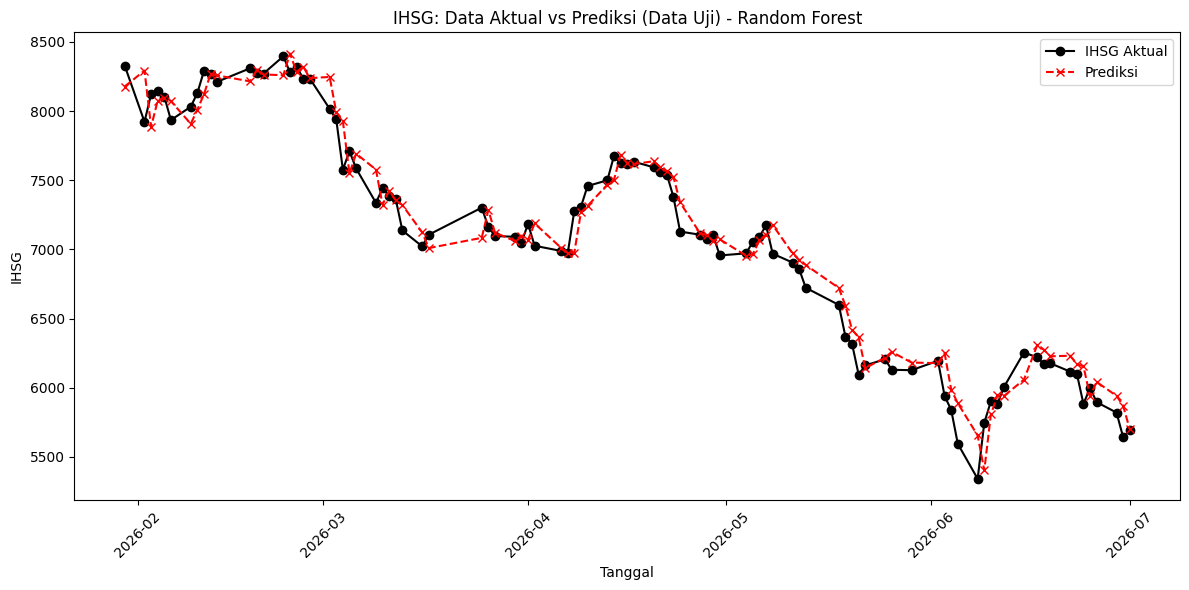

In [ ]:
tanggal_test = df['Date'].iloc[-len(y_test):].reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(tanggal_test, y_test_harga, label='IHSG Aktual', color='black', marker='o')
plt.plot(tanggal_test, pred_harga, label='Prediksi', color='red', linestyle='--', marker='x')

plt.title('IHSG: Data Aktual vs Prediksi (Data Uji) - Random Forest')
plt.xlabel('Tanggal')
plt.ylabel('IHSG')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafik Tingkat Kepentingan Fitur

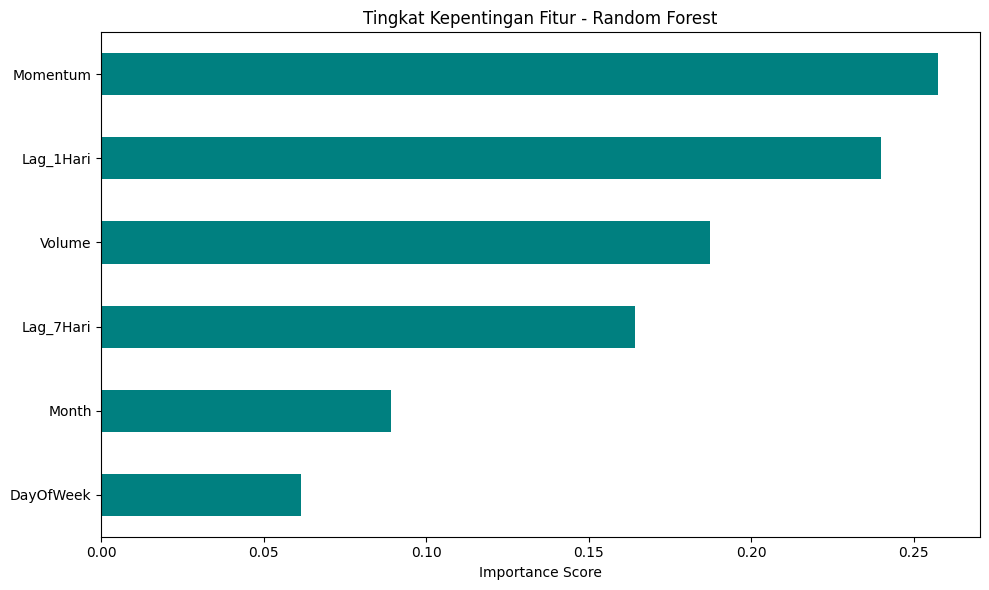

In [ ]:
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='teal')
plt.title('Tingkat Kepentingan Fitur - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
riwayat_ihsg = df['IHSG'].tolist()
volume_rata2 = df['Vol.'].tail(7).mean()
tanggal_terakhir = df['Date'].max()
tanggal_depan = pd.bdate_range(start=tanggal_terakhir + pd.Timedelta(days=1), periods=7)

prediksi_depan = []
for tgl in tanggal_depan:
    lag1 = riwayat_ihsg[-1]
    lag7 = riwayat_ihsg[-7]
    momentum = lag1 - lag7
    fitur_baru = pd.DataFrame([[lag1, lag7, momentum, volume_rata2, tgl.dayofweek, tgl.month]],
                              columns=fitur)
    selisih_pred = model.predict(fitur_baru)[0]
    pred_val = lag1 + selisih_pred   # rekonstruksi harga = harga kemarin + prediksi selisih
    prediksi_depan.append(pred_val)
    riwayat_ihsg.append(pred_val)

hasil_forecast = pd.DataFrame({'Tanggal': tanggal_depan.date, 'Prediksi_IHSG': np.round(prediksi_depan, 2)})
print("Prediksi IHSG 7 Hari ke Depan:\n")
print(hasil_forecast.to_string(index=False))

print(f"\nHarga aktual terakhir ({df['Date'].max().date()}): {df['IHSG'].iloc[-1]:.2f}")
selisih_hari_pertama = prediksi_depan[0] - df['IHSG'].iloc[-1]
persen_selisih = selisih_hari_pertama / df['IHSG'].iloc[-1] * 100
print(f"Selisih prediksi hari pertama vs harga aktual terakhir: {selisih_hari_pertama:+.2f} ({persen_selisih:+.2f}%)")

Prediksi IHSG 7 Hari ke Depan:

   Tanggal  Prediksi_IHSG
2026-07-02        5746.74
2026-07-03        5791.49
2026-07-06        5836.40
2026-07-07        5892.77
2026-07-08        5948.64
2026-07-09        6003.76
2026-07-10        6058.42

Harga aktual terakhir (2026-07-01): 5695.12
Selisih prediksi hari pertama vs harga aktual terakhir: +51.62 (+0.91%)


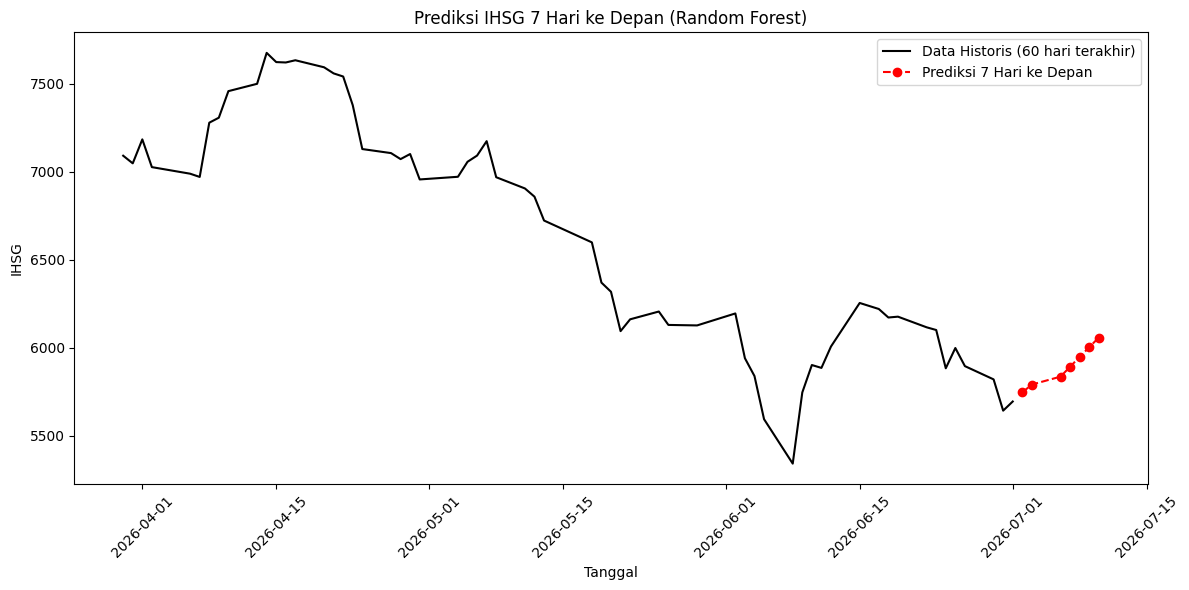

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'].tail(60), df['IHSG'].tail(60), label='Data Historis (60 hari terakhir)', color='black')
plt.plot(tanggal_depan, prediksi_depan, label='Prediksi 7 Hari ke Depan', color='red', marker='o', linestyle='--')

plt.title('Prediksi IHSG 7 Hari ke Depan (Random Forest)')
plt.xlabel('Tanggal')
plt.ylabel('IHSG')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()